# 06 · Limitaciones, riesgo de modelo y comunicación de resultados

**Edición docente · 8 de octubre de 2026 · Modelos Predictivos en Negocios**

**Unidad 3 · Semanas 11–12 · RA3 (CE 3.3–3.5) · 150–180 minutos.**
Examinarás dónde puede fallar el modelo de abandono de FinCordillera: desempeño por segmento, estabilidad, deriva y sensibilidad a costos. Con esa evidencia redactarás una ficha del modelo, recomendaciones de mejora y mensajes para audiencias distintas.

**Cómo trabajar:** ejecuta desde la primera celda. Antes de mover un control, escribe qué esperas que ocurra;
después compara y justifica la diferencia. Los casos son docentes: FinCordillera, QuillayMarket y PulpaLenga son
empresas ficticias con datos simulados del repositorio; las simulaciones adicionales se identifican como tales.

Los controles requieren JupyterLab con `ipywidgets` y un kernel activo; las salidas guardadas permiten leer los
resultados sin ejecutar. Cada función interactiva también puede llamarse directamente con argumentos.

[Guía maestra](../guia_maestra_mpn.html) · [Manual científico](../material_propio/MPN_manual_cientifico.pdf) ·
[Cobertura curricular](../COBERTURA.md)

In [1]:
from pathlib import Path
import sys
import warnings
RAIZ = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "_transversal" / "datos").is_dir()), None)
if RAIZ is None:
    raise FileNotFoundError("Abra Jupyter desde el repositorio completo o una subcarpeta.")
CURSO = RAIZ / "03_Modelos_Predictivos_Negocios"
sys.path.insert(0, str(CURSO / "reproducibilidad"))
import mpn_recursos as mr
from mpn_recursos import pregunta, SEMILLA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown
%matplotlib inline
plt.rcParams.update({"figure.figsize": (8, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .18, "font.size": 10})
pd.set_option("display.max_columns", 16)
pd.set_option("display.float_format",
              lambda v: f"{v:,.0f}" if abs(v) >= 1e4 or float(v).is_integer() else f"{v:,.3f}")
print(f"Python {sys.version.split()[0]} · pandas {pd.__version__} · semilla {SEMILLA}")

Python 3.12.13 · pandas 3.0.6 · semilla 2026


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score

banco = mr.fincordillera_clientes()
X = banco.drop(columns=["cliente_id", "churn"]); y = banco["churn"]
numericas = X.select_dtypes("number").columns.tolist(); categoricas = ["region"]
Xe, Xv, Xt, ye, yv, yt = mr.particion_tres(X, y)
def nuevo_modelo():
    return Pipeline([("preparar", mr.preprocesador(numericas, categoricas)),
                     ("modelo", LogisticRegression(max_iter=2000))])
modelo = nuevo_modelo().fit(Xe, ye)
C_FN, C_FP = 5.0, 1.0                     # costos relativos: perder un cliente frente a contactarlo sin necesidad
p_val = modelo.predict_proba(Xv)[:, 1]
tabla = mr.tabla_umbrales(yv, p_val, C_FN, C_FP)
umbral = float(tabla.loc[tabla["costo_medio"].idxmin(), "umbral"])
p_prueba = modelo.predict_proba(Xt)[:, 1]
resumen_prueba = mr.metricas_umbral(yt, p_prueba, umbral, C_FN, C_FP)
resumen_prueba.update(mr.ks_gini(yt, p_prueba))
display(pd.Series(resumen_prueba).to_frame("prueba · logística · umbral de validación"))

,prueba · logística · umbral de validación
umbral,0.140
TN,44
FP,93
FN,5
TP,48
accuracy,0.484
precision,0.340
recall,0.906
F1,0.495
costo_medio,0.621


<a id="segmentos"></a>

## Desempeño por segmento: promedio global frente a grupos (CE 3.3)

Un AUC global puede ocultar grupos donde el modelo funciona peor. Para tener una predicción fuera de muestra de
**cada** cliente se usan predicciones fuera de pliegue (validación cruzada de 5 pliegues). Para cada región se
informa tamaño, tasa observada, probabilidad media estimada (**calibración en el agregado**), AUC con intervalo
bootstrap y recall en el umbral elegido. Un intervalo amplio indica que el grupo es pequeño, no que el modelo sea malo.

In [3]:
cv = StratifiedKFold(5, shuffle=True, random_state=SEMILLA)
p_oof = cross_val_predict(nuevo_modelo(), X, y, cv=cv, method="predict_proba")[:, 1]
g = np.random.default_rng(SEMILLA)
filas = []
for region, idx in banco.groupby("region").groups.items():
    yr, pr = y.loc[idx].to_numpy(), p_oof[banco.index.get_indexer(idx)]
    boot = []
    for _ in range(300):
        i = g.integers(0, len(yr), len(yr))
        if 0 < yr[i].sum() < len(i):
            boot.append(roc_auc_score(yr[i], pr[i]))
    filas.append({"región": region, "clientes": len(yr), "tasa observada": yr.mean(), "probabilidad media": pr.mean(),
                  "AUC": roc_auc_score(yr, pr), "AUC IC90 inf": np.quantile(boot, .05), "AUC IC90 sup": np.quantile(boot, .95),
                  "recall en umbral": mr.metricas_umbral(yr, pr, umbral)["recall"]})
segmentos = pd.DataFrame(filas).set_index("región").sort_values("clientes", ascending=False)
display(segmentos)

,clientes,tasa observada,probabilidad media,AUC,AUC IC90 inf,AUC IC90 sup,recall en umbral
región,,,,,,,
Metropolitana,366,0.301,0.299,0.721,0.673,0.767,0.945
Biobio,166,0.259,0.260,0.691,0.615,0.758,0.837
Valparaiso,155,0.232,0.229,0.737,0.658,0.808,0.833
La Araucania,138,0.341,0.335,0.783,0.710,0.855,0.936
Antofagasta,125,0.240,0.249,0.750,0.674,0.830,0.967


**Lectura.** Las diferencias de AUC entre regiones son menores que la amplitud de sus intervalos: no hay evidencia
de que el modelo discrimine peor en una región. Sí conviene revisar la **calibración por grupo**: si una región tiene
tasa observada superior a la probabilidad media estimada, el modelo subestima su riesgo y la campaña la
desatendería. En variables sensibles (edad, género, comuna) esta revisión es además una exigencia ética y regulatoria.

<a id="estabilidad"></a>

## Estabilidad: ¿cambiaría el modelo con otra muestra?

Se reajusta el modelo en 200 muestras bootstrap de entrenamiento y se observa la distribución de cada razón de
chances. Un coeficiente cuyo intervalo cruza 1 tiene signo incierto: no debería sostener una recomendación.

In [4]:
nombres = [n.split("__")[-1] for n in modelo.named_steps["preparar"].get_feature_names_out()]
g = np.random.default_rng(SEMILLA)
coeficientes = []
for _ in range(200):
    i = g.integers(0, len(Xe), len(Xe))
    m = nuevo_modelo().fit(Xe.iloc[i], ye.iloc[i])
    coeficientes.append(m.named_steps["modelo"].coef_[0])
coeficientes = pd.DataFrame(np.exp(coeficientes), columns=nombres)
estabilidad = pd.DataFrame({"razón de chances (mediana)": coeficientes.median(),
                            "IC90 inf": coeficientes.quantile(.05), "IC90 sup": coeficientes.quantile(.95)})
estabilidad["signo estable"] = (estabilidad["IC90 inf"] > 1) | (estabilidad["IC90 sup"] < 1)
display(estabilidad.sort_values("razón de chances (mediana)", ascending=False))

,razón de chances (mediana),IC90 inf,IC90 sup,signo estable
region_La Araucania,2.024,1.232,3.353,True
frecuencia_reclamos_12m,1.801,1.487,2.177,True
retrasos_pago_12m,1.596,1.368,1.974,True
region_Biobio,1.454,0.890,2.337,False
region_Valparaiso,1.332,0.821,2.255,False
region_Metropolitana,1.111,0.717,1.672,False
edad,0.920,0.799,1.108,False
ingreso_mensual_clp,0.791,0.685,0.940,True
antiguedad_meses,0.788,0.659,0.949,True
uso_app_movil_mensual,0.786,0.672,0.902,True


<a id="deriva"></a>

## Deriva: cuando los clientes futuros no se parecen a los de entrenamiento

Un modelo supone que la relación entre $X$ e $Y$ y la distribución de $X$ se mantienen. El **Population Stability
Index** compara la distribución de una variable o del puntaje entre una población de referencia y una nueva:

$$\text{PSI} = \sum_k (a_k - e_k)\,\ln\frac{a_k}{e_k},$$

donde $e_k$ y $a_k$ son proporciones en el tramo $k$. Una convención habitual en riesgo de crédito —no una ley—
interpreta PSI < 0,10 como estable, 0,10–0,25 como cambio moderado y > 0,25 como cambio significativo. El control
**simula** un mes con más reclamos (por ejemplo, tras una falla de servicio) y una cartera más joven. Sin etiquetas
nuevas no se puede medir el AUC del mes: se monitorean PSI y la tasa predicha.

In [5]:
referencia = modelo.predict_proba(X)[:, 1]
def explorar_deriva(reclamos_extra=1.0, rejuvenecimiento_anios=0):
    g = np.random.default_rng(SEMILLA + 11)
    nuevo = X.sample(600, replace=True, random_state=SEMILLA).copy()
    nuevo["frecuencia_reclamos_12m"] = nuevo["frecuencia_reclamos_12m"] + g.poisson(reclamos_extra, len(nuevo))
    nuevo["edad"] = (nuevo["edad"] - rejuvenecimiento_anios).clip(lower=18)
    puntaje = modelo.predict_proba(nuevo)[:, 1]
    resultado = pd.Series({"PSI del puntaje": mr.psi(referencia, puntaje),
                           "PSI de reclamos": mr.psi(X["frecuencia_reclamos_12m"], nuevo["frecuencia_reclamos_12m"]),
                           "PSI de edad": mr.psi(X["edad"], nuevo["edad"]),
                           "tasa predicha referencia": referencia.mean(), "tasa predicha nueva": puntaje.mean()})
    estado = ("estable" if resultado["PSI del puntaje"] < .10 else
              "cambio moderado: investigar" if resultado["PSI del puntaje"] < .25 else "cambio significativo: revisar o recalibrar")
    display(resultado.to_frame("mes simulado")); display(Markdown(f"**Estado del puntaje:** {estado}."))
    return resultado

deriva_base = explorar_deriva()
widgets.interact(explorar_deriva,
                 reclamos_extra=widgets.FloatSlider(value=1, min=0, max=3, step=.25, description="reclamos +λ"),
                 rejuvenecimiento_anios=widgets.IntSlider(value=0, min=0, max=20, description="edad −años"));

,mes simulado
PSI del puntaje,0.143
PSI de reclamos,0.464
PSI de edad,0.026
tasa predicha referencia,0.279
tasa predicha nueva,0.355


**Estado del puntaje:** cambio moderado: investigar.

interactive(children=(FloatSlider(value=1.0, description='reclamos +λ', max=3.0, step=0.25), IntSlider(value=0…

**Lectura.** Un aumento de reclamos desplaza el puntaje y la tasa predicha. Puede reflejar un riesgo real mayor
(la falla del servicio) o un cambio en cómo se registran los reclamos: el PSI detecta el cambio, no su causa.
Rejuvenecer la cartera mueve el PSI de edad, pero casi no el del puntaje, porque la edad pesa poco en este modelo:
una variable puede derivar sin que el modelo cambie su decisión.

<a id="sensibilidad-costos"></a>

## Sensibilidad a los supuestos de costo

El umbral depende de la razón $c_{FN}/c_{FP}$, que la gerencia conoce de forma aproximada. Se recorre esa razón y
se compara el umbral de menor costo en validación con la regla teórica $t^*=c_{FP}/(c_{FP}+c_{FN})$.

,umbral de menor costo (validación),t* teórico,recall en ese umbral
c_FN / c_FP,,,
1,0.470,0.500,0.283
2,0.410,0.333,0.377
3,0.190,0.250,0.830
5,0.140,0.167,0.925
8,0.140,0.111,0.925
12,0.070,0.077,1
20,0.070,0.048,1


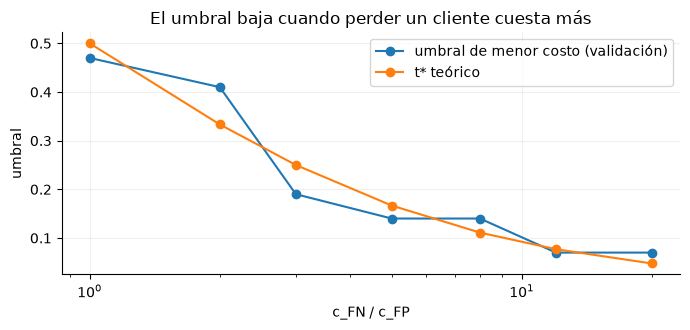

In [6]:
razones = [1, 2, 3, 5, 8, 12, 20]
sensibilidad = []
for r_ in razones:
    t = mr.tabla_umbrales(yv, p_val, c_fn=r_, c_fp=1)
    u = float(t.loc[t["costo_medio"].idxmin(), "umbral"])
    sensibilidad.append({"c_FN / c_FP": r_, "umbral de menor costo (validación)": u, "t* teórico": mr.umbral_bayes(r_, 1),
                         "recall en ese umbral": mr.metricas_umbral(yv, p_val, u)["recall"]})
sensibilidad = pd.DataFrame(sensibilidad).set_index("c_FN / c_FP")
display(sensibilidad)
sensibilidad[["umbral de menor costo (validación)", "t* teórico"]].plot(marker="o", figsize=(7, 3.4),
    title="El umbral baja cuando perder un cliente cuesta más", logx=True)
plt.ylabel("umbral"); plt.tight_layout(); plt.show()

<a id="ficha"></a>

## Ficha del modelo (*model card*)

Una ficha documenta para qué sirve el modelo, con qué datos se construyó, cómo se evaluó, dónde falla y cómo se
monitorea. Es el insumo de un comité de riesgo de modelos y la memoria del proyecto. Se genera con las cifras
calculadas en este notebook.

In [7]:
ficha = {
    "Propósito": "Priorizar clientes para una oferta de retención trimestral; no decide por sí solo.",
    "Uso no permitido": "Negar productos o cambiar condiciones de crédito.",
    "Datos": f"{len(banco)} clientes simulados de FinCordillera; tasa de abandono {y.mean():.1%}.",
    "Variables": ", ".join(numericas + categoricas),
    "Modelo": "Regresión logística con variables estandarizadas (scikit-learn).",
    "Evaluación en prueba": (f"AUC {resumen_prueba['AUC']:.3f}; KS {resumen_prueba['KS']:.3f}; recall {resumen_prueba['recall']:.2f}; "
                             f"precisión {resumen_prueba['precision']:.2f} con umbral {umbral:.2f}."),
    "Supuestos de decisión": f"Costo relativo c_FN/c_FP = {C_FN:.0f}; umbral elegido en validación.",
    "Limitaciones": "Datos simulados de un período; sin variables de interacción con el banco; regiones pequeñas con incertidumbre alta.",
    "Monitoreo": "PSI mensual del puntaje (alerta > 0,10; revisión > 0,25); tasa predicha frente a observada cada trimestre.",
    "Responsables y revisión": "Analista (desarrollo), riesgo de modelos (validación independiente); revisión semestral.",
}
display(Markdown("| Campo | Contenido |\n|---|---|\n" + "\n".join(f"| {k} | {v} |" for k, v in ficha.items())))

| Campo | Contenido |
|---|---|
| Propósito | Priorizar clientes para una oferta de retención trimestral; no decide por sí solo. |
| Uso no permitido | Negar productos o cambiar condiciones de crédito. |
| Datos | 950 clientes simulados de FinCordillera; tasa de abandono 28.0%. |
| Variables | edad, antiguedad_meses, ingreso_mensual_clp, num_productos_contratados, frecuencia_reclamos_12m, retrasos_pago_12m, uso_app_movil_mensual, region |
| Modelo | Regresión logística con variables estandarizadas (scikit-learn). |
| Evaluación en prueba | AUC 0.728; KS 0.392; recall 0.91; precisión 0.34 con umbral 0.14. |
| Supuestos de decisión | Costo relativo c_FN/c_FP = 5; umbral elegido en validación. |
| Limitaciones | Datos simulados de un período; sin variables de interacción con el banco; regiones pequeñas con incertidumbre alta. |
| Monitoreo | PSI mensual del puntaje (alerta > 0,10; revisión > 0,25); tasa predicha frente a observada cada trimestre. |
| Responsables y revisión | Analista (desarrollo), riesgo de modelos (validación independiente); revisión semestral. |

<a id="mejoras"></a>

## Recomendaciones de mejora estructuradas (CE 3.5)

Cada recomendación responde a una limitación con **evidencia**, una **acción** y una **métrica de verificación**.

| Limitación | Evidencia | Recomendación | Cómo se verifica |
|---|---|---|---|
| Probabilidades usadas como riesgo absoluto | Ordenamiento bueno; calibración por grupo variable | Revisar calibración por región y recalibrar si es necesario | Probabilidad media ≈ tasa observada por grupo; Brier |
| Umbral sensible a costos inciertos | El umbral cambia al variar $c_{FN}/c_{FP}$ | Acordar costos con finanzas y documentar el rango | Costo esperado estable en el rango acordado |
| Coeficientes de signo incierto | Intervalos bootstrap que cruzan 1 | No usarlos para recomendaciones de negocio | Intervalo fuera de 1 con más datos |
| Deriva de reclamos | PSI del puntaje sube en el escenario simulado | Monitoreo mensual con alerta y plan de recalibración | PSI < 0,10 o recalibración documentada |
| Efecto causal no identificado | El modelo predice, no explica por qué se van | Piloto con grupo de control antes de escalar | Diferencia de abandono contactados/control |

<a id="comunicacion"></a>

## Comunicar a audiencias distintas (CE 3.4)

La estructura **Situación–Complicación–Resolución** ordena el mensaje: contexto conocido, problema o hallazgo y
recomendación con su incertidumbre. La misma evidencia se cuenta distinto a un directorio, a una gerencia
comercial y a un comité de riesgo de modelos. El control genera cada versión con las cifras calculadas.

In [8]:
captura = mr.lift_deciles(yt, p_prueba, grupos=5)["captura_acumulada"].iloc[0]
def explorar_mensaje(audiencia="Directorio"):
    if audiencia == "Directorio":
        texto = (f"**Situación:** cerca de {y.mean():.0%} de los clientes abandona cada trimestre. **Complicación:** retener a "
                 f"todos es caro y la oferta indiscriminada se desperdicia. **Resolución:** un modelo permite enfocar la "
                 f"oferta; en datos reservados, el 20% de mayor riesgo concentró cerca de {captura:.0%} de los abandonos. "
                 "Proponemos un piloto con grupo de control antes de escalar.")
    elif audiencia == "Gerencia comercial":
        texto = (f"Con el umbral {umbral:.2f}, la lista detecta {resumen_prueba['recall']:.0%} de quienes se van y "
                 f"{resumen_prueba['precision']:.0%} de los contactados efectivamente iba a abandonar. Si el costo de "
                 "contacto sube, conviene subir el umbral; el notebook 04 muestra el beneficio bajo distintos supuestos. "
                 "La lista se actualiza mensualmente.")
    else:
        texto = (f"Logística estandarizada; AUC prueba {resumen_prueba['AUC']:.3f}, KS {resumen_prueba['KS']:.3f}; umbral "
                 f"elegido en validación con c_FN/c_FP={C_FN:.0f}. Sin diferencias de discriminación concluyentes por región; "
                 "coeficientes estables en reclamos y retrasos. Riesgos: datos simulados de un período, sensibilidad a "
                 "costos y deriva de reclamos. Plan: PSI mensual y validación independiente semestral.")
    display(Markdown(f"**{audiencia}.** " + texto))
    return texto

mensaje_base = explorar_mensaje()
widgets.interact(explorar_mensaje, audiencia=widgets.Dropdown(
    options=["Directorio", "Gerencia comercial", "Comité de riesgo de modelos"], value="Directorio"));

**Directorio.** **Situación:** cerca de 28% de los clientes abandona cada trimestre. **Complicación:** retener a todos es caro y la oferta indiscriminada se desperdicia. **Resolución:** un modelo permite enfocar la oferta; en datos reservados, el 20% de mayor riesgo concentró cerca de 42% de los abandonos. Proponemos un piloto con grupo de control antes de escalar.

interactive(children=(Dropdown(description='audiencia', options=('Directorio', 'Gerencia comercial', 'Comité d…

<a id="caso-informe"></a>

## Lectura crítica de un informe de modelo

Un equipo presenta este resumen de un informe de abandono para **Telco Coigüe**, operador ficticio:

> *«Comparamos regresión logística, árbol y bosque aleatorio siguiendo las seis fases de CRISP-DM. El bosque
> obtuvo AUC 0,86 en la muestra de prueba, donde además elegimos el umbral que maximiza el beneficio: contactar
> al 18% de los clientes genera un beneficio de 41 millones por trimestre. La región Sur abandona más, por lo que
> recomendamos concentrar allí la campaña.»*

La estructura es buena —resumen con cifras, fases, criterio de negocio y umbral económico—, pero conviene aplicar
esta lista de revisión antes de usarlo como referencia:

| Pregunta de revisión | En el informe de Telco Coigüe |
|---|---|
| ¿Las métricas finales se calcularon en datos no usados para decidir? | No: el umbral se eligió en la prueba; el beneficio informado es optimista y debe separarse una validación |
| ¿Se informa incertidumbre? | Solo cifras puntuales; faltan intervalos o variación entre pliegues |
| ¿Los supuestos de costo están declarados? | No se explican el valor del cliente ni el costo de contacto |
| ¿Hay análisis por segmento? | Se compara la tasa de abandono por región, no el desempeño del modelo por región |
| ¿Se distingue predicción de causalidad? | No: contactar no garantiza retener; se necesita un piloto con control |
| ¿Están los datos y el código para reproducirlo? | No se mencionan: el informe no es reproducible |

### Ejercicios resueltos

1. **PSI.** Si 30% de los clientes estaba en el tramo de mayor riesgo y ahora está 45%, solo ese tramo aporta
   $(0{,}45-0{,}30)\ln(0{,}45/0{,}30)\approx0{,}061$ al PSI.
2. **Grupo pequeño.** Una región con 90 clientes y AUC 0,70 frente a 0,80 global: ¿discriminación peor? Solo si el
   intervalo del grupo excluye el valor global; con 90 casos el intervalo suele ser amplio.
3. **Mensaje.** «El modelo tiene 82% de accuracy» es un mal mensaje para un directorio: no dice qué decisión mejora
   ni cuánto vale. Mejor: «enfocando la oferta en el 20% de mayor riesgo alcanzamos cerca de 40% de los abandonos».

In [9]:
auto_06 = pregunta("El PSI del puntaje sube a 0,30 en un mes, pero aún no hay etiquetas de abandono. ¿Qué corresponde?",
                   ["Concluir que el AUC cayó y retirar el modelo de inmediato",
                    "Investigar la causa del cambio (población, registro o proceso) y preparar recalibración; medir desempeño cuando lleguen etiquetas",
                    "Ignorarlo, porque sin etiquetas no hay evidencia"], 1,
                   "El PSI detecta cambio de distribución, no su causa ni la pérdida de desempeño; activa una revisión.")
assert segmentos["clientes"].sum() == len(banco)
assert estabilidad.loc["frecuencia_reclamos_12m", "signo estable"] and estabilidad.loc["retrasos_pago_12m", "signo estable"]
from IPython.utils import io
with io.capture_output():
    sin_deriva, con_deriva = explorar_deriva(0, 0), explorar_deriva(3, 0)
assert sin_deriva["PSI del puntaje"] < .10 < con_deriva["PSI del puntaje"]
assert sensibilidad["umbral de menor costo (validación)"].iloc[-1] <= sensibilidad["umbral de menor costo (validación)"].iloc[0]
print("Comprobaciones del laboratorio 06: OK")

Comprobaciones del laboratorio 06: OK


### Referencias

Mitchell et al., «Model Cards for Model Reporting», *FAT\* 2019*, [arXiv:1810.03993](https://arxiv.org/abs/1810.03993) ·
Board of Governors of the Federal Reserve System, *SR 11-7: Guidance on Model Risk Management* (2011) ·
Siddiqi, *Credit Risk Scorecards* (Wiley, 2006), para PSI · Minto, *The Pyramid Principle* (estructura SCR).